# 02. 리뷰/인기도 EDA: 사용자의 실제 선호를 어떻게 수치화할 것인가

## 비즈니스 질문

별점만 높은 장소는 리뷰 수가 적어도 상위에 올라갈 수 있다.
따라서 **리뷰 수, 평균 평점, 긍정 점수**를 함께 고려해 더 안정적인 인기도를 만들었다.

## 왜 이 계산법을 썼나

- 리뷰 수는 관심도의 크기지만, 인기 장소 쏠림이 크기 때문에 로그 변환이 필요하다.
- 평균 평점은 만족도지만, 리뷰 수가 적으면 불안정하므로 베이지안 보정이 필요하다.
- 긍정 점수는 텍스트 리뷰의 실제 감정을 반영한다.



In [22]:
from pathlib import Path
import sys, os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# matplotlib 캐시는 이 EDA 폴더 안에만 만들도록 고정한다.
MPL_CACHE_DIR = Path(r'C:/Users/hyunj/Seoul_Strolling_Adventure/Business_Impact_EDA/.matplotlib_cache')
MPL_CACHE_DIR.mkdir(exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPL_CACHE_DIR))

import matplotlib
if 'ipykernel' not in sys.modules:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'Business_Impact_EDA' else Path(r'C:/Users/hyunj/Seoul_Strolling_Adventure')

# 노트북/Colab/로컬 환경에서 한글 폰트가 깨지지 않도록 설정
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
    get_ipython().run_line_magic('config', "InlineBackend.figure_format = 'retina'")
except Exception:
    pass

import os
import shutil
import subprocess
import matplotlib as mpl
from matplotlib import font_manager as fm

# Colab/Linux 계열이면 나눔/Noto CJK 폰트 설치를 시도한다.
# Windows 로컬에서는 apt-get이 없으므로 설치를 건너뛰고 Malgun Gothic을 우선 사용한다.
if shutil.which('apt-get'):
    try:
        subprocess.run(['apt-get', 'update', '-qq'], check=False)
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum', 'fonts-nanum-extra', 'fonts-noto-cjk'],
                       check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    except Exception as e:
        print('폰트 설치 단계 건너뜀:', e)

# 캐시 삭제 & 폰트 매니저 재로딩
try:
    shutil.rmtree(mpl.get_cachedir(), ignore_errors=True)
    Path(mpl.get_cachedir()).mkdir(parents=True, exist_ok=True)
    fm._load_fontmanager(try_read_cache=False)
except Exception as e:
    print('폰트 캐시 초기화 단계 건너뜀:', e)

# 우선순위: Colab/Linux용 나눔바른고딕 > 나눔고딕 > Noto CJK > Windows 맑은 고딕
candidates = ['NanumBarunGothic', 'NanumGothic', 'Noto Sans CJK KR', 'Malgun Gothic', 'AppleGothic']
avail = {name: any(name in font.name for font in fm.fontManager.ttflist) for name in candidates}
chosen = next((name for name in candidates if avail.get(name)), 'DejaVu Sans')

sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = [chosen]
plt.rcParams['axes.unicode_minus'] = False
print('Using font:', chosen)

def read_csv(path, **kwargs):
    for enc in ['utf-8-sig', 'utf-8', 'cp949']:
        try:
            return pd.read_csv(path, encoding=enc, **kwargs)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path, **kwargs)

def find_csv_by_cols(folder, required_cols):
    for p in sorted(Path(folder).rglob('*.csv')):
        try:
            cols = set(read_csv(p, nrows=0).columns)
            if set(required_cols).issubset(cols):
                return p
        except Exception:
            pass
    raise FileNotFoundError(f'{folder} 안에서 컬럼 {required_cols}를 가진 csv를 찾지 못했습니다.')

def pct(a, b):
    if b == 0 or pd.isna(b):
        return np.nan
    return (a - b) / b * 100

DATA = {
    'ui_places': find_csv_by_cols(PROJECT_ROOT / 'UI', ['title', 'tour_score', 'review_score']),
    'congestion': find_csv_by_cols(PROJECT_ROOT / 'UI' / 'congestion_level', ['시간대', 'final_level']),
    'tourism_index': next(PROJECT_ROOT.rglob('final_data_Tourism.csv')),
    'popularity': PROJECT_ROOT / 'EDA' / 'popularity' / 'popularity_result.csv',
    'reviews': PROJECT_ROOT / 'EDA' / 'popularity' / 'zb_review_data_final.csv',
}

print('PROJECT_ROOT =', PROJECT_ROOT)
print('사용 데이터 존재 여부')
for k, v in DATA.items():
    print(f'{k:15s}: {v.exists()} | {v.relative_to(PROJECT_ROOT)}')






Using font: NanumGothic
PROJECT_ROOT = c:\Users\hyunj\Seoul_Strolling_Adventure
사용 데이터 존재 여부
ui_places      : True | UI\관광지_법정동_매핑결과.csv
congestion     : True | UI\congestion_level\혼잡도 최종등급_전국.csv
tourism_index  : True | EDA\관광지수\final_data_Tourism.csv
popularity     : True | EDA\popularity\popularity_result.csv
reviews        : True | EDA\popularity\zb_review_data_final.csv


In [23]:
pop = read_csv(DATA['popularity'])
reviews = read_csv(DATA['reviews'], parse_dates=False)
pop.head(), reviews.head()


(      행정구          행정동 카테고리   리뷰수      평균평점    평균긍정점수     로그리뷰수      보정평점  \
 0  서울 종로구  종로1·2·3·4가동   문화   391  4.468031  8.282123  5.971262  4.444345   
 1  경기 수원시          행궁동   문화   218  4.683486  8.566147  5.389072  4.626004   
 2  서울 종로구        청운효자동   문화   315  4.498413  8.176667  5.755742  4.467678   
 3  서울 강남구          청담동   음식   894  3.916107  7.367494  6.796824  3.916378   
 4  서울 성동구       성수2가3동   음식  1141  3.880806  7.121735  7.040536  3.881568   
 
      보정긍정점수       인기도  
 0  8.239667  6.222646  
 1  8.470906  6.147862  
 2  8.130222  6.117599  
 3  7.366506  6.065457  
 4  7.124775  6.062781  ,
       검색어     장소명   평점                   주소    리뷰닉네임   별점           날짜  \
 0  가나아트파크  가나아트파크  3.2  경기도 양주시 장흥면 권율로 117      짜다짜  3.0  2025.03.03.   
 1  가나아트파크  가나아트파크  3.2  경기도 양주시 장흥면 권율로 117     리커버리  4.0  2025.02.15.   
 2  가나아트파크  가나아트파크  3.2  경기도 양주시 장흥면 권율로 117      BC😊  4.0  2024.06.02.   
 3  가나아트파크  가나아트파크  3.2  경기도 양주시 장흥면 권율로 117      포뇨v  4.0  2023.06.05.   
 4  

In [24]:
reviews['연도월_dt'] = pd.to_datetime(reviews['연도월'].astype(str), errors='coerce')
monthly = reviews.dropna(subset=['연도월_dt']).groupby('연도월_dt').agg(
    review_count=('리뷰내용', 'size'),
    avg_rating=('별점', 'mean'),
    positive_score=('긍정점수', 'mean')
).reset_index().sort_values('연도월_dt')

# 마지막 월은 크롤링/수집 기간이 덜 찬 부분월일 수 있다.
# 직전 3개월 중앙값의 70% 미만이면 부분집계로 보고 성장률 계산에서는 제외한다.
monthly_for_growth = monthly.copy()
partial_month_note = '없음'
if len(monthly_for_growth) >= 4:
    last_count = monthly_for_growth['review_count'].iloc[-1]
    prev_median = monthly_for_growth['review_count'].iloc[-4:-1].median()
    if last_count < prev_median * 0.7:
        partial_month_note = f"{monthly_for_growth['연도월_dt'].iloc[-1].strftime('%Y-%m')} 부분집계 가능성으로 성장률 계산에서 제외"
        monthly_for_growth = monthly_for_growth.iloc[:-1].copy()

recent = monthly_for_growth.tail(6).copy()
review_growth = pct(recent['review_count'].iloc[-1], recent['review_count'].iloc[0]) if len(recent) >= 2 else np.nan
positive_growth = pct(recent['positive_score'].iloc[-1], recent['positive_score'].iloc[0]) if len(recent) >= 2 else np.nan
print('부분월 보정:', partial_month_note)
print(f'최근 완전월 기준 {len(recent)}개월 리뷰 수 변화율: {review_growth:.1f}%')
print(f'최근 완전월 기준 {len(recent)}개월 긍정점수 변화율: {positive_growth:.1f}%')
recent


부분월 보정: 2025-04 부분집계 가능성으로 성장률 계산에서 제외
최근 완전월 기준 6개월 리뷰 수 변화율: 18.3%
최근 완전월 기준 6개월 긍정점수 변화율: 3.4%


,연도월_dt,review_count,avg_rating,positive_score
21,2024-10-01,6852,3.790280,6.985607
22,2024-11-01,6416,3.824813,7.043892
23,2024-12-01,5989,3.765236,6.927542
24,2025-01-01,6926,3.858793,7.077577
25,2025-02-01,6703,3.909444,7.150937
26,2025-03-01,8105,3.908698,7.223398


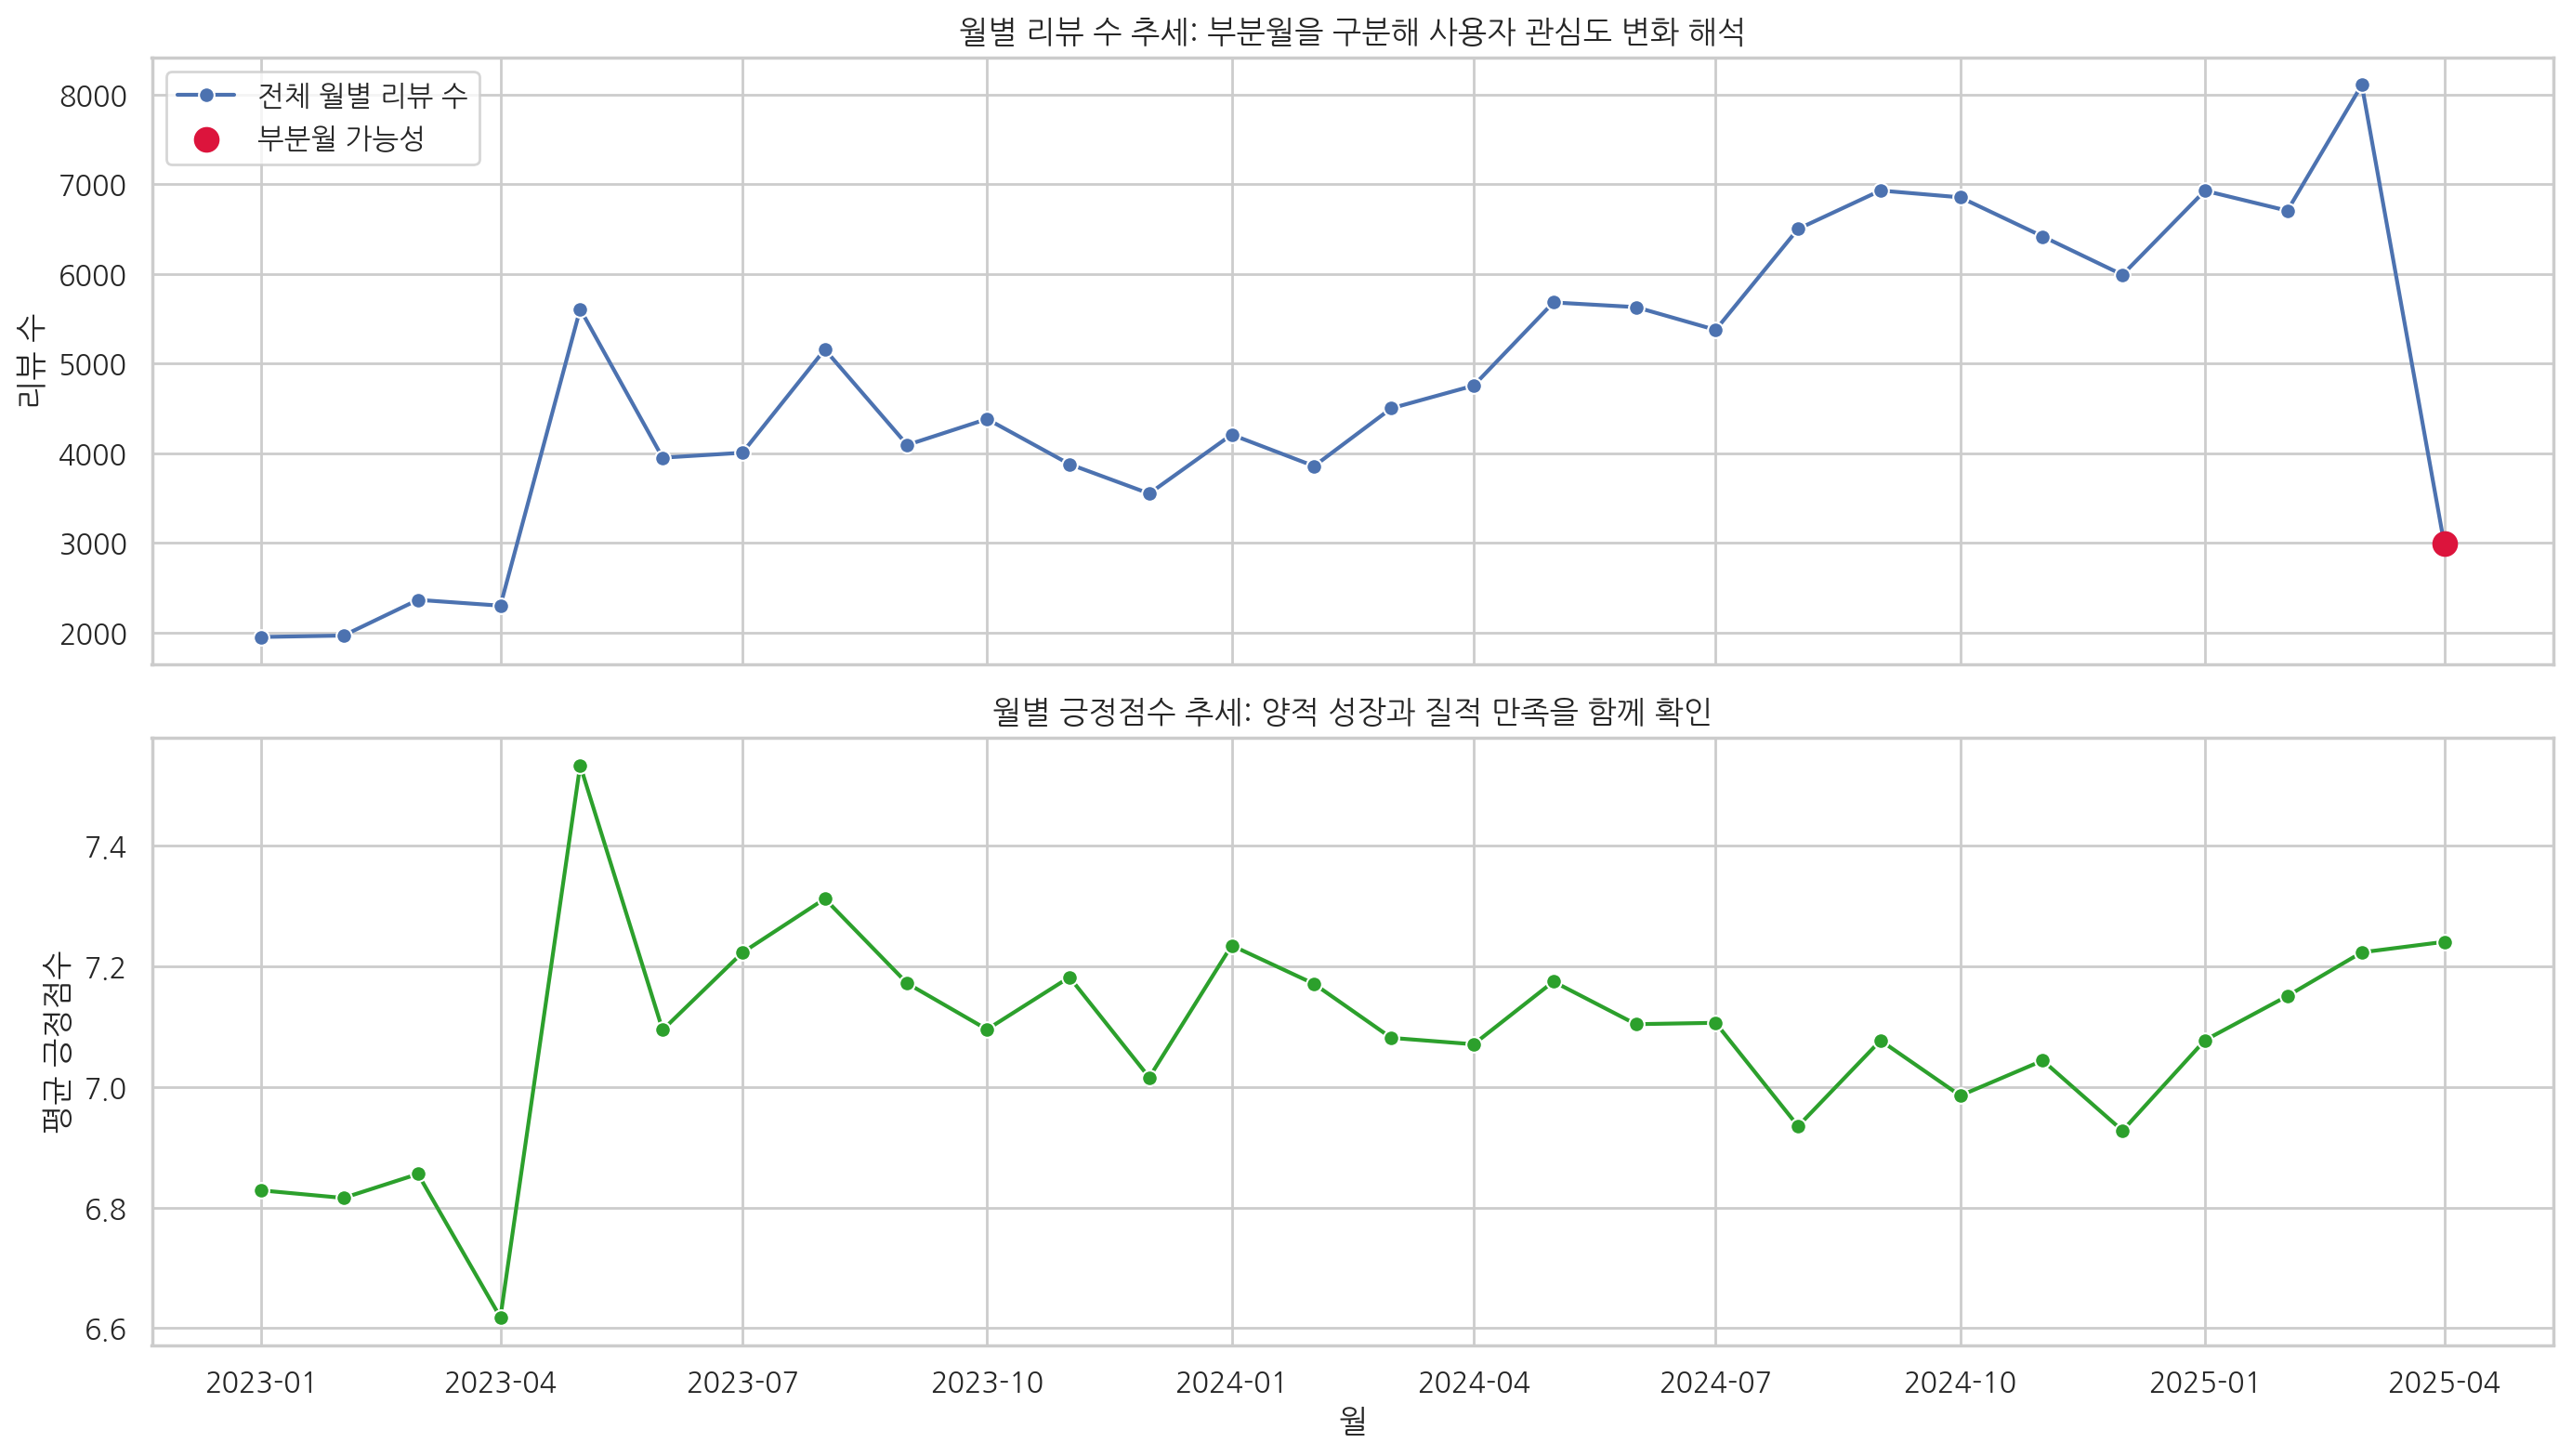

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
sns.lineplot(data=monthly, x='연도월_dt', y='review_count', marker='o', ax=axes[0], label='전체 월별 리뷰 수')
if 'monthly_for_growth' in globals() and len(monthly_for_growth) < len(monthly):
    axes[0].scatter(monthly['연도월_dt'].iloc[-1], monthly['review_count'].iloc[-1], color='crimson', s=80, zorder=5, label='부분월 가능성')
axes[0].set_title('월별 리뷰 수 추세: 부분월을 구분해 사용자 관심도 변화 해석')
axes[0].set_ylabel('리뷰 수')
axes[0].legend()

sns.lineplot(data=monthly, x='연도월_dt', y='positive_score', marker='o', color='tab:green', ax=axes[1])
axes[1].set_title('월별 긍정점수 추세: 양적 성장과 질적 만족을 함께 확인')
axes[1].set_ylabel('평균 긍정점수')
axes[1].set_xlabel('월')
plt.tight_layout()
plt.show()


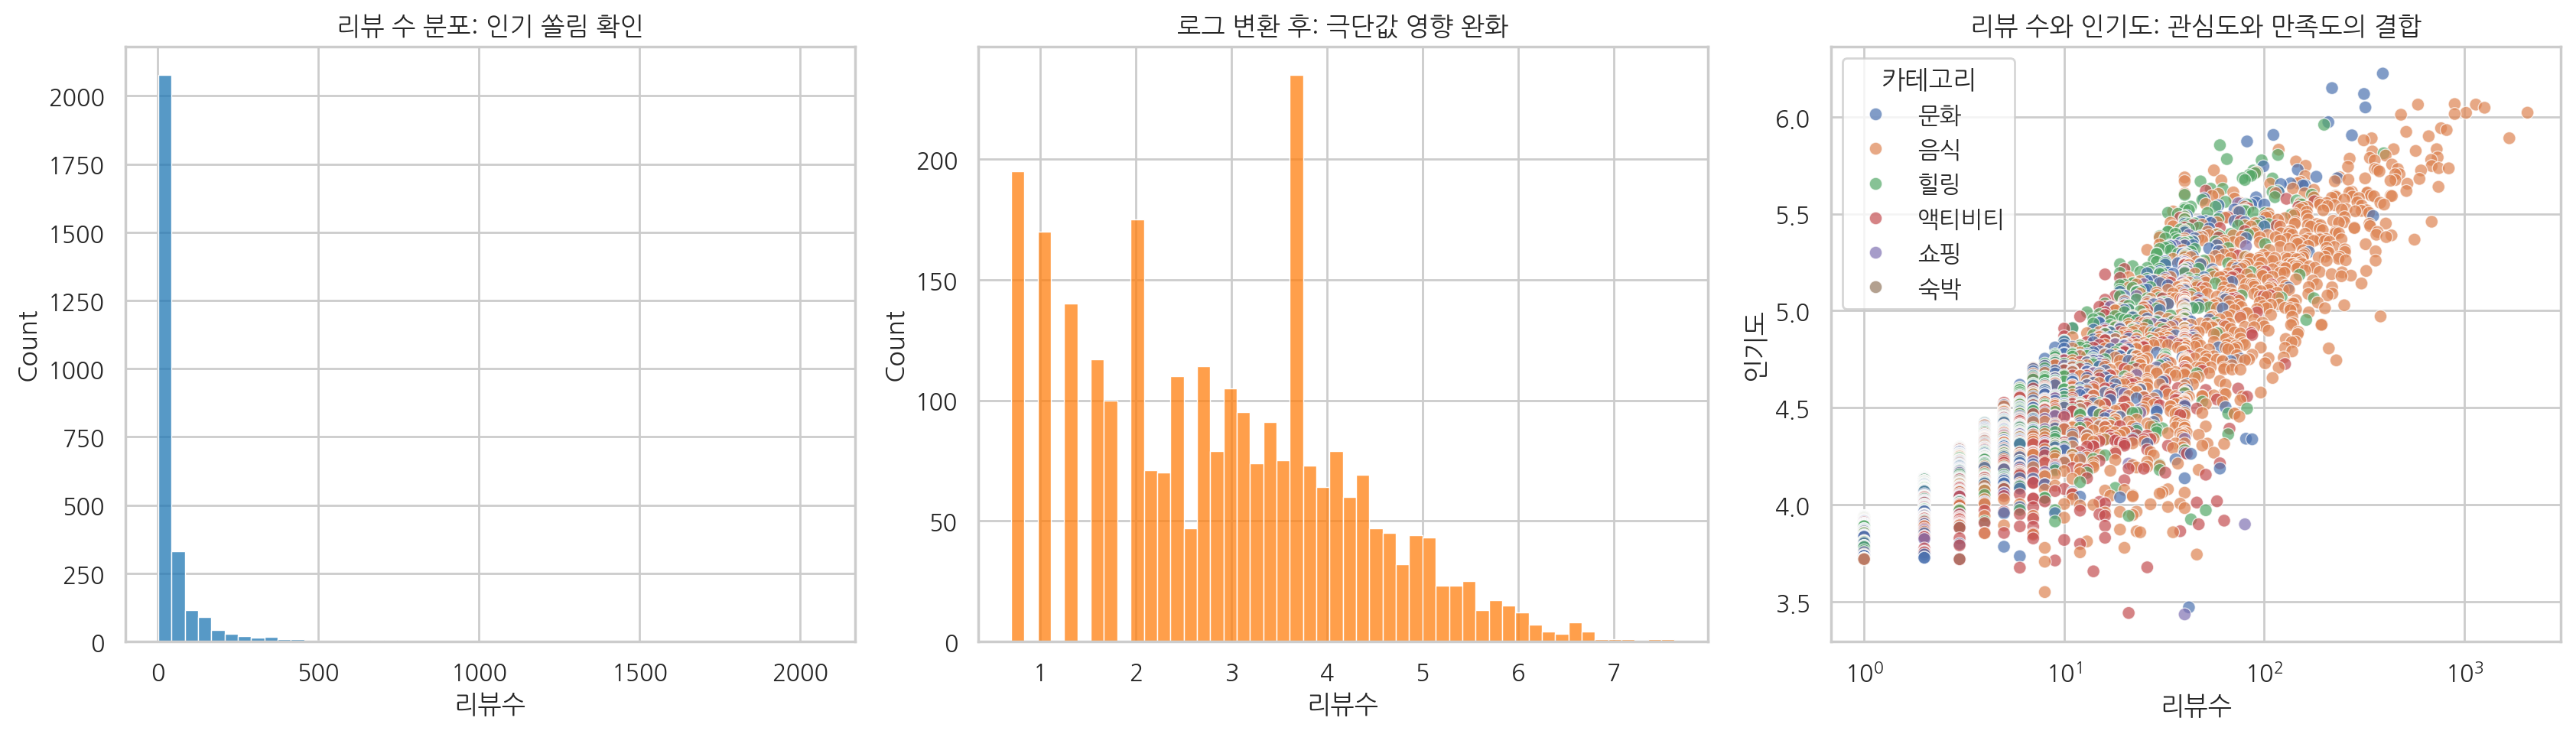

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sns.histplot(pop['리뷰수'], bins=50, ax=axes[0], color='tab:blue')
axes[0].set_title('리뷰 수 분포: 인기 쏠림 확인')
sns.histplot(np.log1p(pop['리뷰수']), bins=50, ax=axes[1], color='tab:orange')
axes[1].set_title('로그 변환 후: 극단값 영향 완화')
sns.scatterplot(data=pop, x='리뷰수', y='인기도', hue='카테고리', alpha=.7, ax=axes[2])
axes[2].set_title('리뷰 수와 인기도: 관심도와 만족도의 결합')
axes[2].set_xscale('log')
plt.tight_layout()
plt.show()


## 검정: 카테고리별 인기도 차이가 있는가?

카테고리에 따라 인기도 평균이 다르면, UI에서 테마별 추천을 분리하는 이유가 생긴다. 단, 표본이 너무 적은 카테고리는 결과가 불안정하므로 n≥20 카테고리만 ANOVA와 박스플롯에 사용한다.



In [27]:
cat_counts = pop['카테고리'].value_counts()
valid_cats = cat_counts[cat_counts >= 20].index
pop_valid = pop[pop['카테고리'].isin(valid_cats)].copy()

groups = [g['인기도'].dropna().values for _, g in pop_valid.groupby('카테고리')]
f_stat, p_value = stats.f_oneway(*groups)
cat_summary = pop_valid.groupby('카테고리').agg(
    count=('인기도', 'size'),
    avg_popularity=('인기도', 'mean'),
    median_popularity=('인기도', 'median'),
    avg_reviews=('리뷰수', 'mean')
).sort_values('avg_popularity', ascending=False)
print(f'ANOVA p-value: {p_value:.4g}')
print(f'분석 제외 카테고리(n<20): {cat_counts[cat_counts < 20].to_dict()}')
cat_summary


ANOVA p-value: 1.155e-65
분석 제외 카테고리(n<20): {'숙박': 1}


,count,avg_popularity,median_popularity,avg_reviews
카테고리,,,,
음식,1127,4.837138,4.849973,87.567879
힐링,550,4.621925,4.514563,22.876364
문화,532,4.523493,4.436568,22.945489
쇼핑,120,4.517011,4.458139,17.375000
액티비티,448,4.384966,4.324712,17.908482


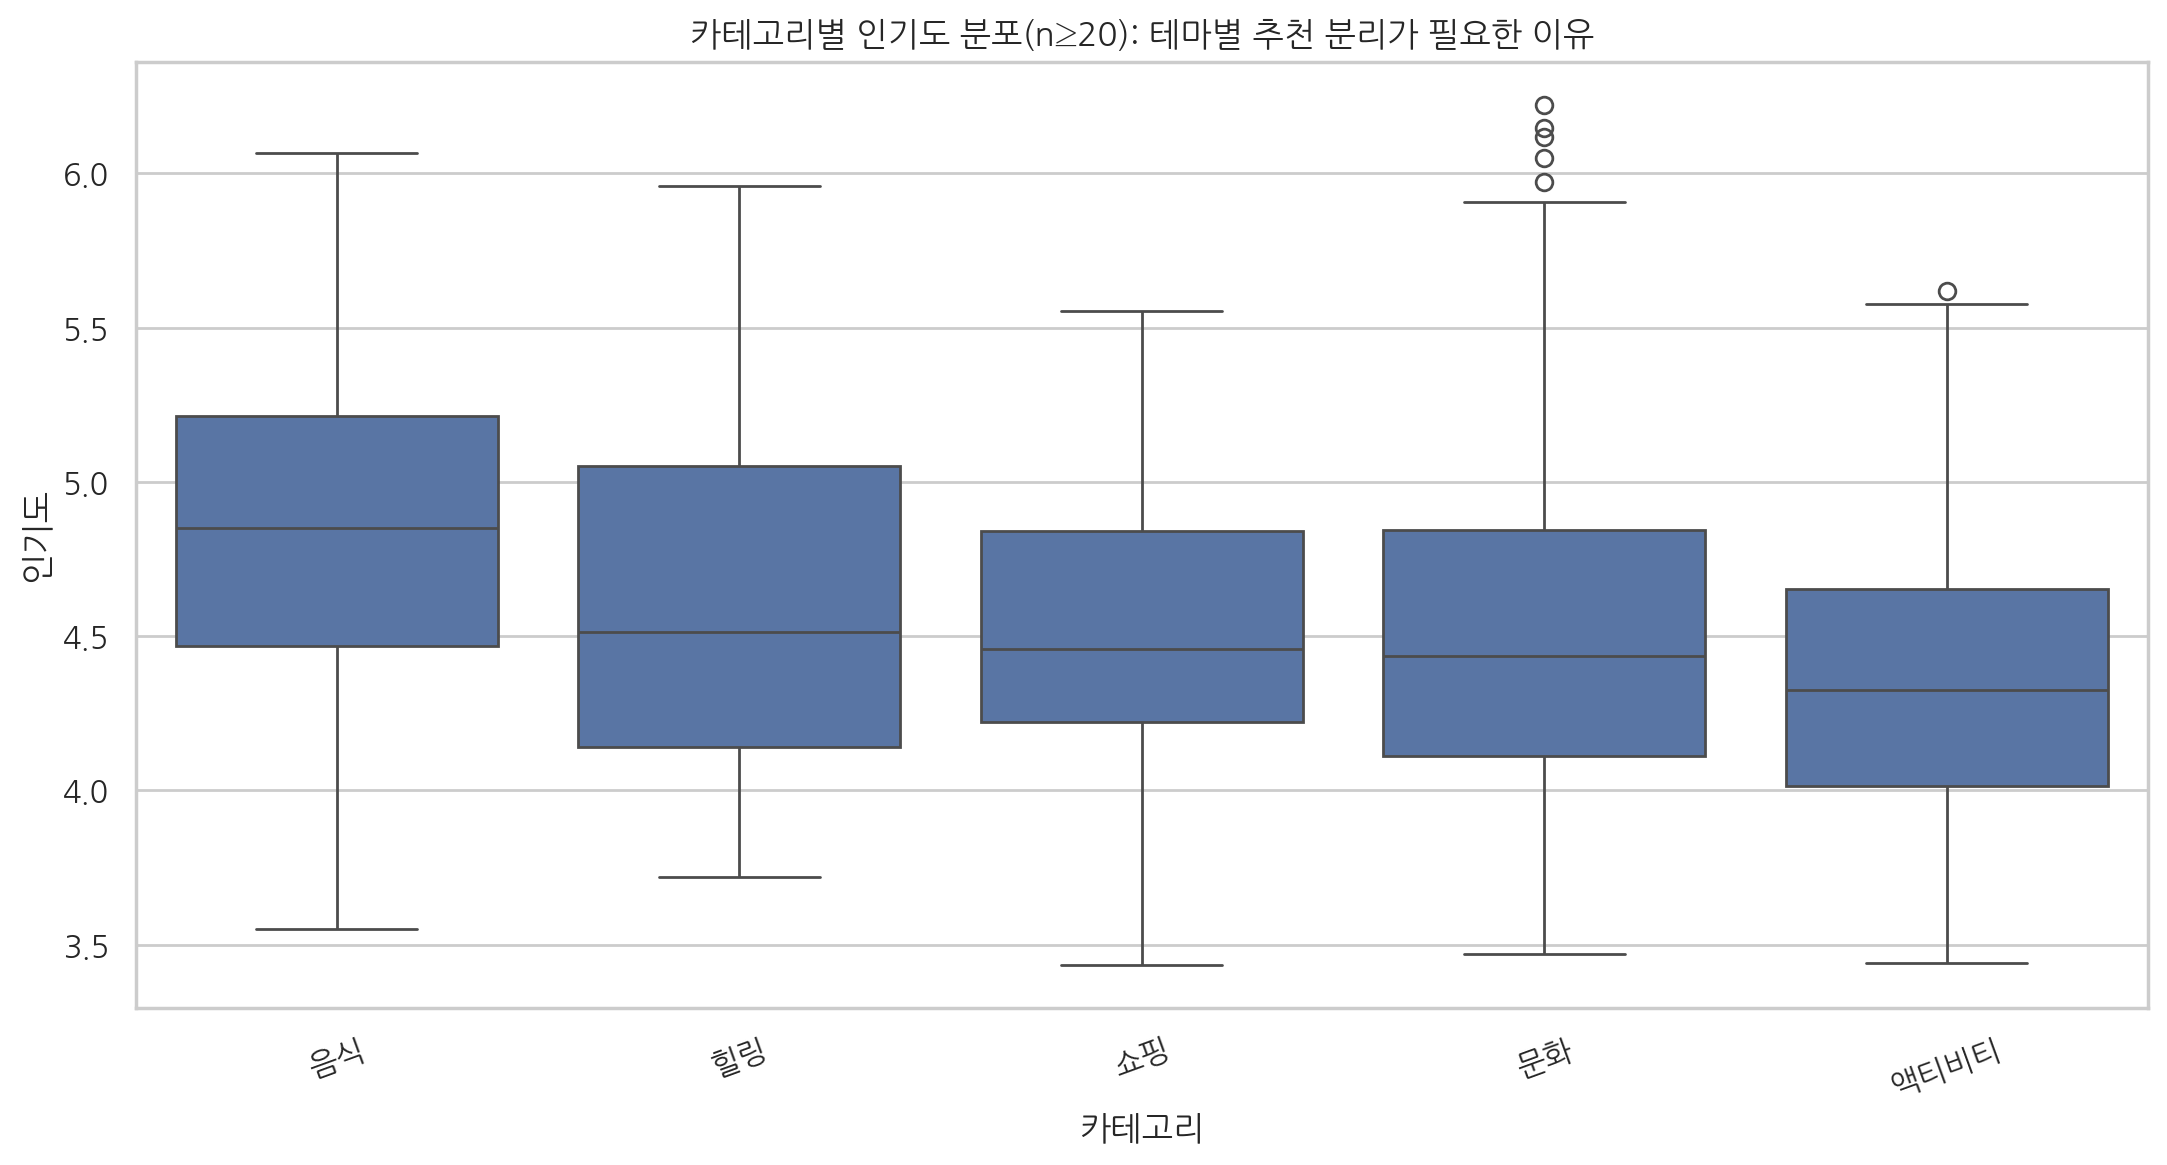

In [28]:
fig, ax = plt.subplots(figsize=(11, 6))
order = pop_valid.groupby('카테고리')['인기도'].median().sort_values(ascending=False).index
sns.boxplot(data=pop_valid, x='카테고리', y='인기도', order=order, ax=ax)
ax.set_title('카테고리별 인기도 분포(n≥20): 테마별 추천 분리가 필요한 이유')
ax.set_xlabel('카테고리')
ax.set_ylabel('인기도')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 리뷰지수 연결 문장

단순 별점 순 추천은 리뷰가 적은 장소가 과대평가될 위험이 있었다. 그래서 리뷰 수를 로그 변환하고, 평점과 긍정 점수를 보정해 인기도를 계산했다. 또한 최근 월별 리뷰 수와 긍정점수 추세를 확인하되, 마지막 월 부분집계 가능성을 분리해 양적 성장과 질적 만족을 안정적으로 해석했다.

